In [2]:
'''
Concrete is the most important material in civil engineering. The concrete compressive strength is a 
__highly nonlinear__ function of age and ingredients. These ingredients include cement, blast furnace slag, fly ash, water, 
superplasticizer, coarse aggregate, and fine aggregate.

Build a multiple linear regression model to predict concrete compressive strength using mixture composition and curing age.
Use the training data to develop your model. You may consider variable selection, transformations, polynomial terms, and interactions.

Submit:

Your final regression formula, e.g., "Strength = 12.8 + 0.083*Cement + ...", as a text entry
- A brief explanation of how you selected the final model, as a text entry
- Predicted strengths for the 30 test observations. 
        Submit a .csv file containing two columns: ID, PredictedStrength

'''

'\nConcrete is the most important material in civil engineering. The concrete compressive strength is a \n__highly nonlinear__ function of age and ingredients. These ingredients include cement, blast furnace slag, fly ash, water, \nsuperplasticizer, coarse aggregate, and fine aggregate.\n\nBuild a multiple linear regression model to predict concrete compressive strength using mixture composition and curing age.\nUse the training data to develop your model. You may consider variable selection, transformations, polynomial terms, and interactions.\n\nSubmit:\n\nYour final regression formula, e.g., "Strength = 12.8 + 0.083*Cement + ...", as a text entry\n- A brief explanation of how you selected the final model, as a text entry\n- Predicted strengths for the 30 test observations. \n        Submit a .csv file containing two columns: ID, PredictedStrength\n\n'

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.compat import lzip

In [4]:
df = pd.read_csv('concrete_training.csv')
print(df)

     Cement  BlastFurnaceSlag  FlyAsh  Water  Superplasticizer  \
0     329.9             170.0     0.0  193.8               8.0   
1     526.1               0.0     0.2  186.8               0.0   
2     391.9              96.6     0.3  157.8              12.0   
3     213.1               0.0   122.1  180.1               5.7   
4     257.0             100.5    78.8  203.0               9.1   
..      ...               ...     ...    ...               ...   
665   369.5             186.0     0.3  190.4               6.7   
666   268.2             111.8    86.2  181.1              10.1   
667   135.8             202.3     0.0  186.0               0.0   
668   383.8               0.0     0.2  185.0               0.0   
669   548.6               0.2     0.7  172.5               0.0   

     CoarseAggregate  FineAggregate   Age  Strength  
0              802.1          812.0  29.0     56.61  
1             1122.1          620.7  14.1     48.40  
2              873.4          925.2  27.8    

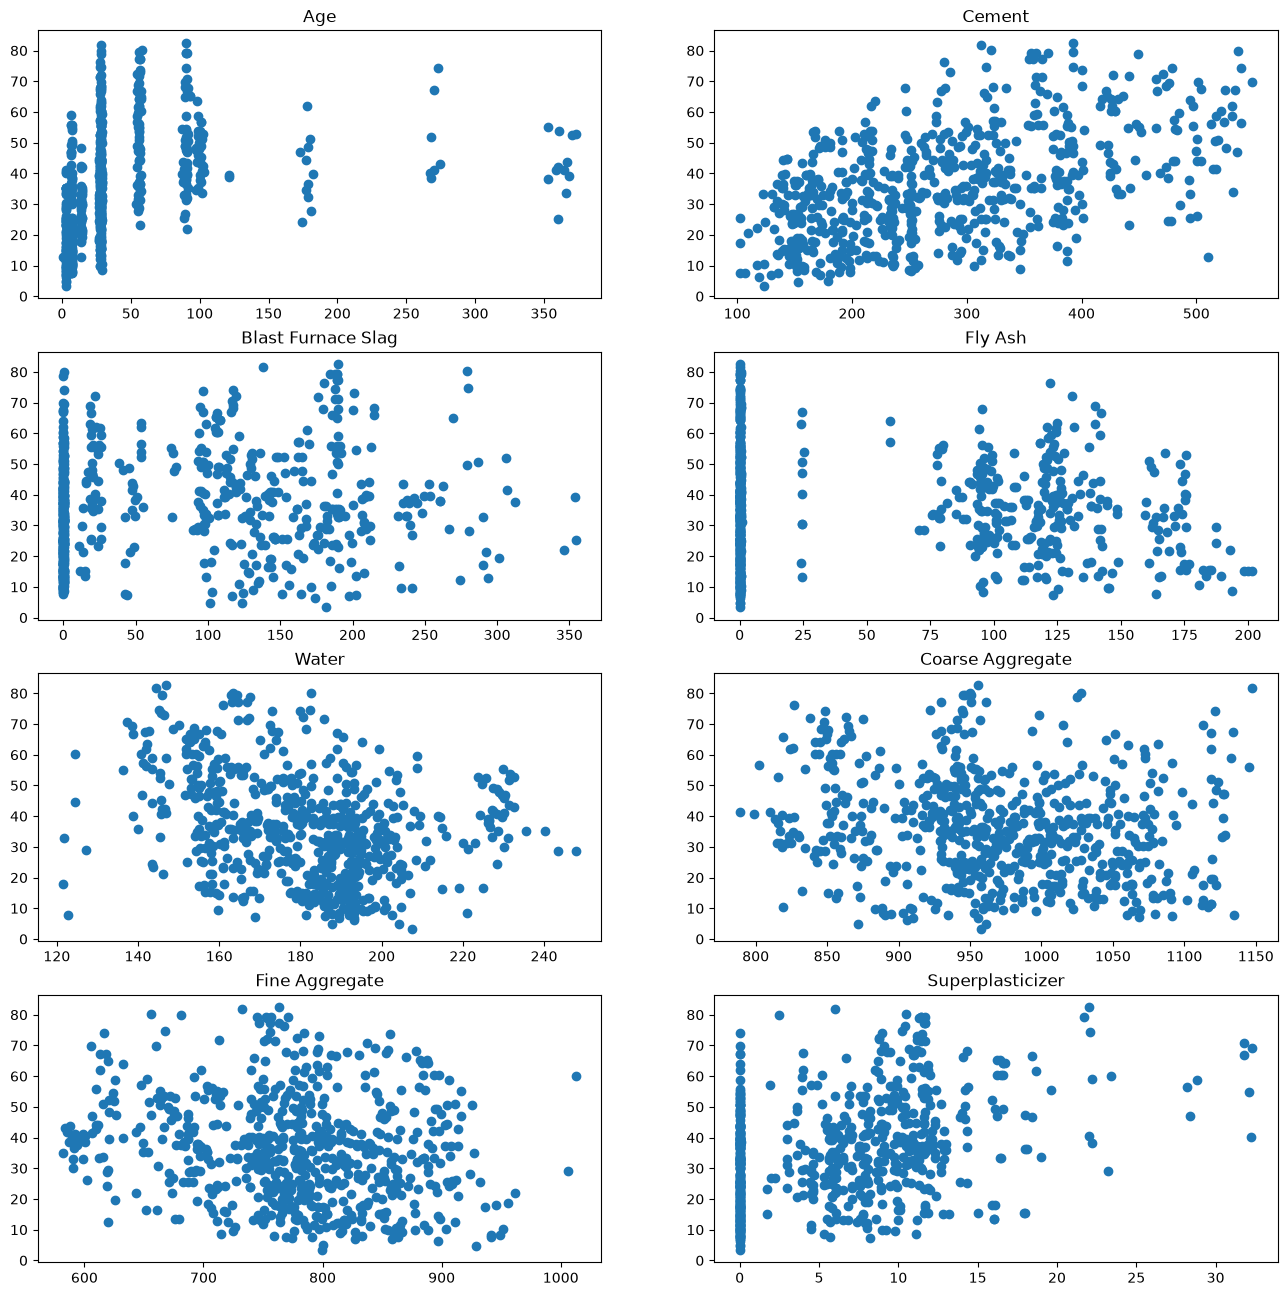

In [5]:
#EDA 
fig = plt.figure(figsize=(16, 16))

age = fig.add_subplot(4,2, 1)
plt.scatter(df.Age, df.Strength)
age.set_title("Age")

cem = fig.add_subplot(4,2, 2)
plt.scatter(df.Cement, df.Strength)
cem.set_title("Cement")

slag = fig.add_subplot(4,2, 3)
plt.scatter(df.BlastFurnaceSlag, df.Strength)
slag.set_title("Blast Furnace Slag")

fly = fig.add_subplot(4,2, 4)
plt.scatter(df.FlyAsh, df.Strength)
fly.set_title("Fly Ash")

water = fig.add_subplot(4,2, 5)
plt.scatter(df.Water, df.Strength)
water.set_title("Water")

ca = fig.add_subplot(4,2, 6)
plt.scatter(df.CoarseAggregate, df.Strength)
ca.set_title("Coarse Aggregate")

fa = fig.add_subplot(4,2, 7)
plt.scatter(df.FineAggregate, df.Strength)
fa.set_title("Fine Aggregate")

sup = fig.add_subplot(4,2, 8)
plt.scatter(df.Superplasticizer, df.Strength)
sup.set_title("Superplasticizer")

plt.show()

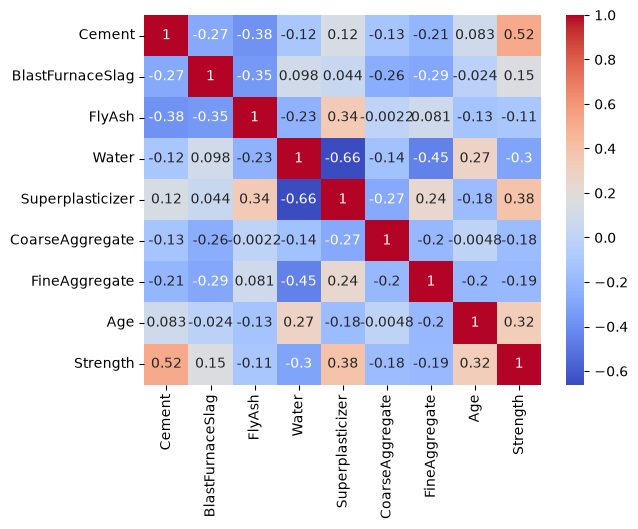

In [6]:
matrix = df.corr()
sns.heatmap(matrix, annot=True, cmap="coolwarm")
plt.show()

In [7]:
#Initial model, using backwards approach
X = df[['Cement', "BlastFurnaceSlag", "FlyAsh", "Water", "Superplasticizer", "CoarseAggregate", "FineAggregate", "Age"]]
y = df['Strength']
X = sm.add_constant(X)
model = sm.OLS(y,X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:               Strength   R-squared:                       0.628
Model:                            OLS   Adj. R-squared:                  0.624
Method:                 Least Squares   F-statistic:                     139.5
Date:                Thu, 01 Oct 2026   Prob (F-statistic):          1.66e-136
Time:                        17:29:13   Log-Likelihood:                -2517.0
No. Observations:                 670   AIC:                             5052.
Df Residuals:                     661   BIC:                             5092.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -7.3851     29.794  

In [ ]:
#removing aggregates due to higher p values

X = df[['Cement', "BlastFurnaceSlag", "FlyAsh", "Water", "Superplasticizer", "Age"]]
y = df['Strength']
X = sm.add_constant(X)
model = sm.OLS(y,X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:               Strength   R-squared:                       0.627
Model:                            OLS   Adj. R-squared:                  0.624
Method:                 Least Squares   F-statistic:                     185.9
Date:                Thu, 01 Oct 2026   Prob (F-statistic):          1.90e-138
Time:                        17:29:13   Log-Likelihood:                -2517.7
No. Observations:                 670   AIC:                             5049.
Df Residuals:                     663   BIC:                             5081.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               26.3594      5.257  

        VIF          variable
0  1.000000             const
1  1.873716            Cement
2  1.791067  BlastFurnaceSlag
3  2.283265            FlyAsh
4  1.942395             Water
5  2.392805  Superplasticizer
6  1.101238               Age
[('LMS', np.float64(87.35284743679794)), ('p', np.float64(1.0737780609429783e-16)), ('f', np.float64(16.566612570408342)), ('f p', np.float64(7.583144290373326e-18))]


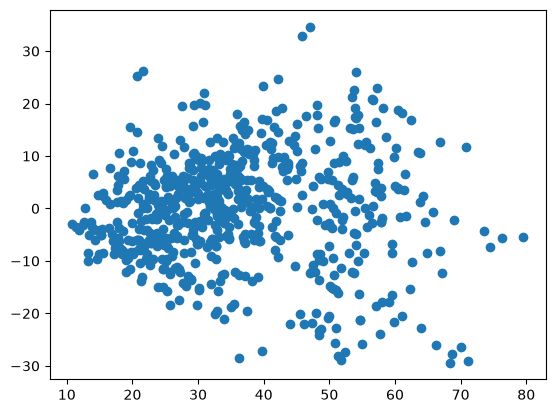

In [9]:
#checking assumptions with resid plot
plt.scatter(results.fittedvalues, results.resid)


vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['variable'] = X.columns
print(vif)

names = ['LMS', 'p', 'f', 'f p']
LMS =sms.het_breuschpagan(results.resid, results.model.exog)

print(lzip(names, LMS))
#Heteroscedacity definitely violated

                            WLS Regression Results                            
Dep. Variable:               Strength   R-squared:                       0.871
Model:                            WLS   Adj. R-squared:                  0.870
Method:                 Least Squares   F-statistic:                     746.6
Date:                Thu, 01 Oct 2026   Prob (F-statistic):          4.91e-291
Time:                        17:29:13   Log-Likelihood:                -2474.7
No. Observations:                 670   AIC:                             4963.
Df Residuals:                     663   BIC:                             4995.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               30.1902      2.951  

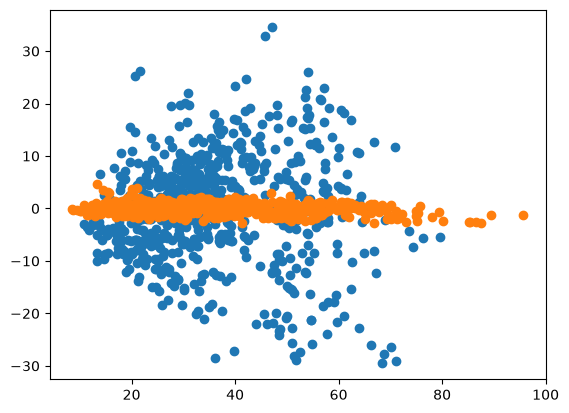

In [ ]:
X = df[['Cement', "BlastFurnaceSlag", "FlyAsh", "Water", "Superplasticizer", "Age"]]
y = df['Strength']
X = sm.add_constant(X)

model1 = sm.OLS(y, X)
results1 = model1.fit()

#regressing the errors from the original helps pin the variance
squared_resid = results1.resid ** 2
var_est = sm.OLS(squared_resid, X).fit()

#lets the weights be properly individualized
pred_var = var_est.fittedvalues
pred_var = np.maximum(pred_var, 1e-6)
weights = 1/pred_var

#run with weights
model2 = sm.WLS(y, X, weights=weights)
results2 = model2.fit()
print(results2.summary())

#Use the weighted for the scatterplot instead of normal to check heteroscedacity fixed 
weight_resid = results2.resid *np.sqrt(weights)
plt.scatter(results1.fittedvalues, results1.resid) #Blue, unweighted
plt.scatter(results2.fittedvalues, weight_resid) #Orange, weighted
plt.show()

In [11]:
'''
Theoretical Formula: y = 0.1238(cement)+ 0.1069(slag)+ 0.0595(flyash) - 0.2603(water) + 0.0128(superplasticizer) + 0.1605(age) + 30.1902

selected via backwards selection then WLS to correct for heteroscedacity due to violation of that assumption, vifs were 

'''

'\nTheoretical Formula: y = 0.1238(cement)+ 0.1069(slag)+ 0.0595(flyash) - 0.2603(water) + 0.0128(superplasticizer) + 0.1605(age) + 30.1902\n\nselected via backwards selection then WLS to correct for heteroscedacity due to violation of that assumption, vifs were \n\n'

In [14]:
#predicting test set strengths with the WLS model (results2)
test = pd.read_csv('concrete_test.csv')

X_test = test[['Cement', "BlastFurnaceSlag", "FlyAsh", "Water", "Superplasticizer", "Age"]]
X_test = sm.add_constant(X_test, has_constant='add')

test_pred = results2.predict(X_test)

predictions = pd.DataFrame({'ID': test['ID'], 'PredictedStrength': test_pred})
print(predictions)
print(predictions['PredictedStrength'].describe())

predictions.to_csv('concrete_predictions.csv', index=False)

    ID  PredictedStrength
0    1          28.956472
1    2          54.211719
2    3          37.703511
3    4          37.547163
4    5          58.145660
5    6          14.334086
6    7          19.512487
7    8          59.535923
8    9          36.854826
9   10          29.921311
10  11          18.585996
11  12          23.420145
12  13          65.938684
13  14          36.723219
14  15          34.160203
15  16          29.714684
16  17          59.600011
17  18          23.229101
18  19          22.146430
19  20          86.495404
20  21          30.249593
21  22          15.685066
22  23          22.805246
23  24          22.751541
24  25          40.988344
25  26           9.019911
26  27          52.156224
27  28          51.387854
28  29          26.421394
29  30          63.478080
count    30.000000
mean     37.056010
std      18.506496
min       9.019911
25%      22.911210
50%      32.204898
75%      51.964132
max      86.495404
Name: PredictedStrength, dtype: float64
